Figure 6c

Input files: ['Input_5_10_111040.png', 'Input_5_10_128139.png', 'Input_5_10_380053.png', 'Input_5_10_308054.png', 'Input_5_10_24138.png']
Simulation files: ['Output_5_10_111040.png', 'Output_5_10_128139.png', 'Output_5_10_380053.png', 'Output_5_10_308054.png', 'Output_5_10_24138.png']
Diffusion files: ['Output_5_10_111040_1.png', 'Output_5_10_111040_2.png', 'Output_5_10_111040_3.png', 'Output_5_10_128139_1.png', 'Output_5_10_128139_2.png', 'Output_5_10_128139_3.png', 'Output_5_10_380053_1.png', 'Output_5_10_380053_2.png', 'Output_5_10_380053_3.png', 'Output_5_10_308054_1.png', 'Output_5_10_308054_2.png', 'Output_5_10_308054_3.png', 'Output_5_10_24138_1.png', 'Output_5_10_24138_2.png', 'Output_5_10_24138_3.png']


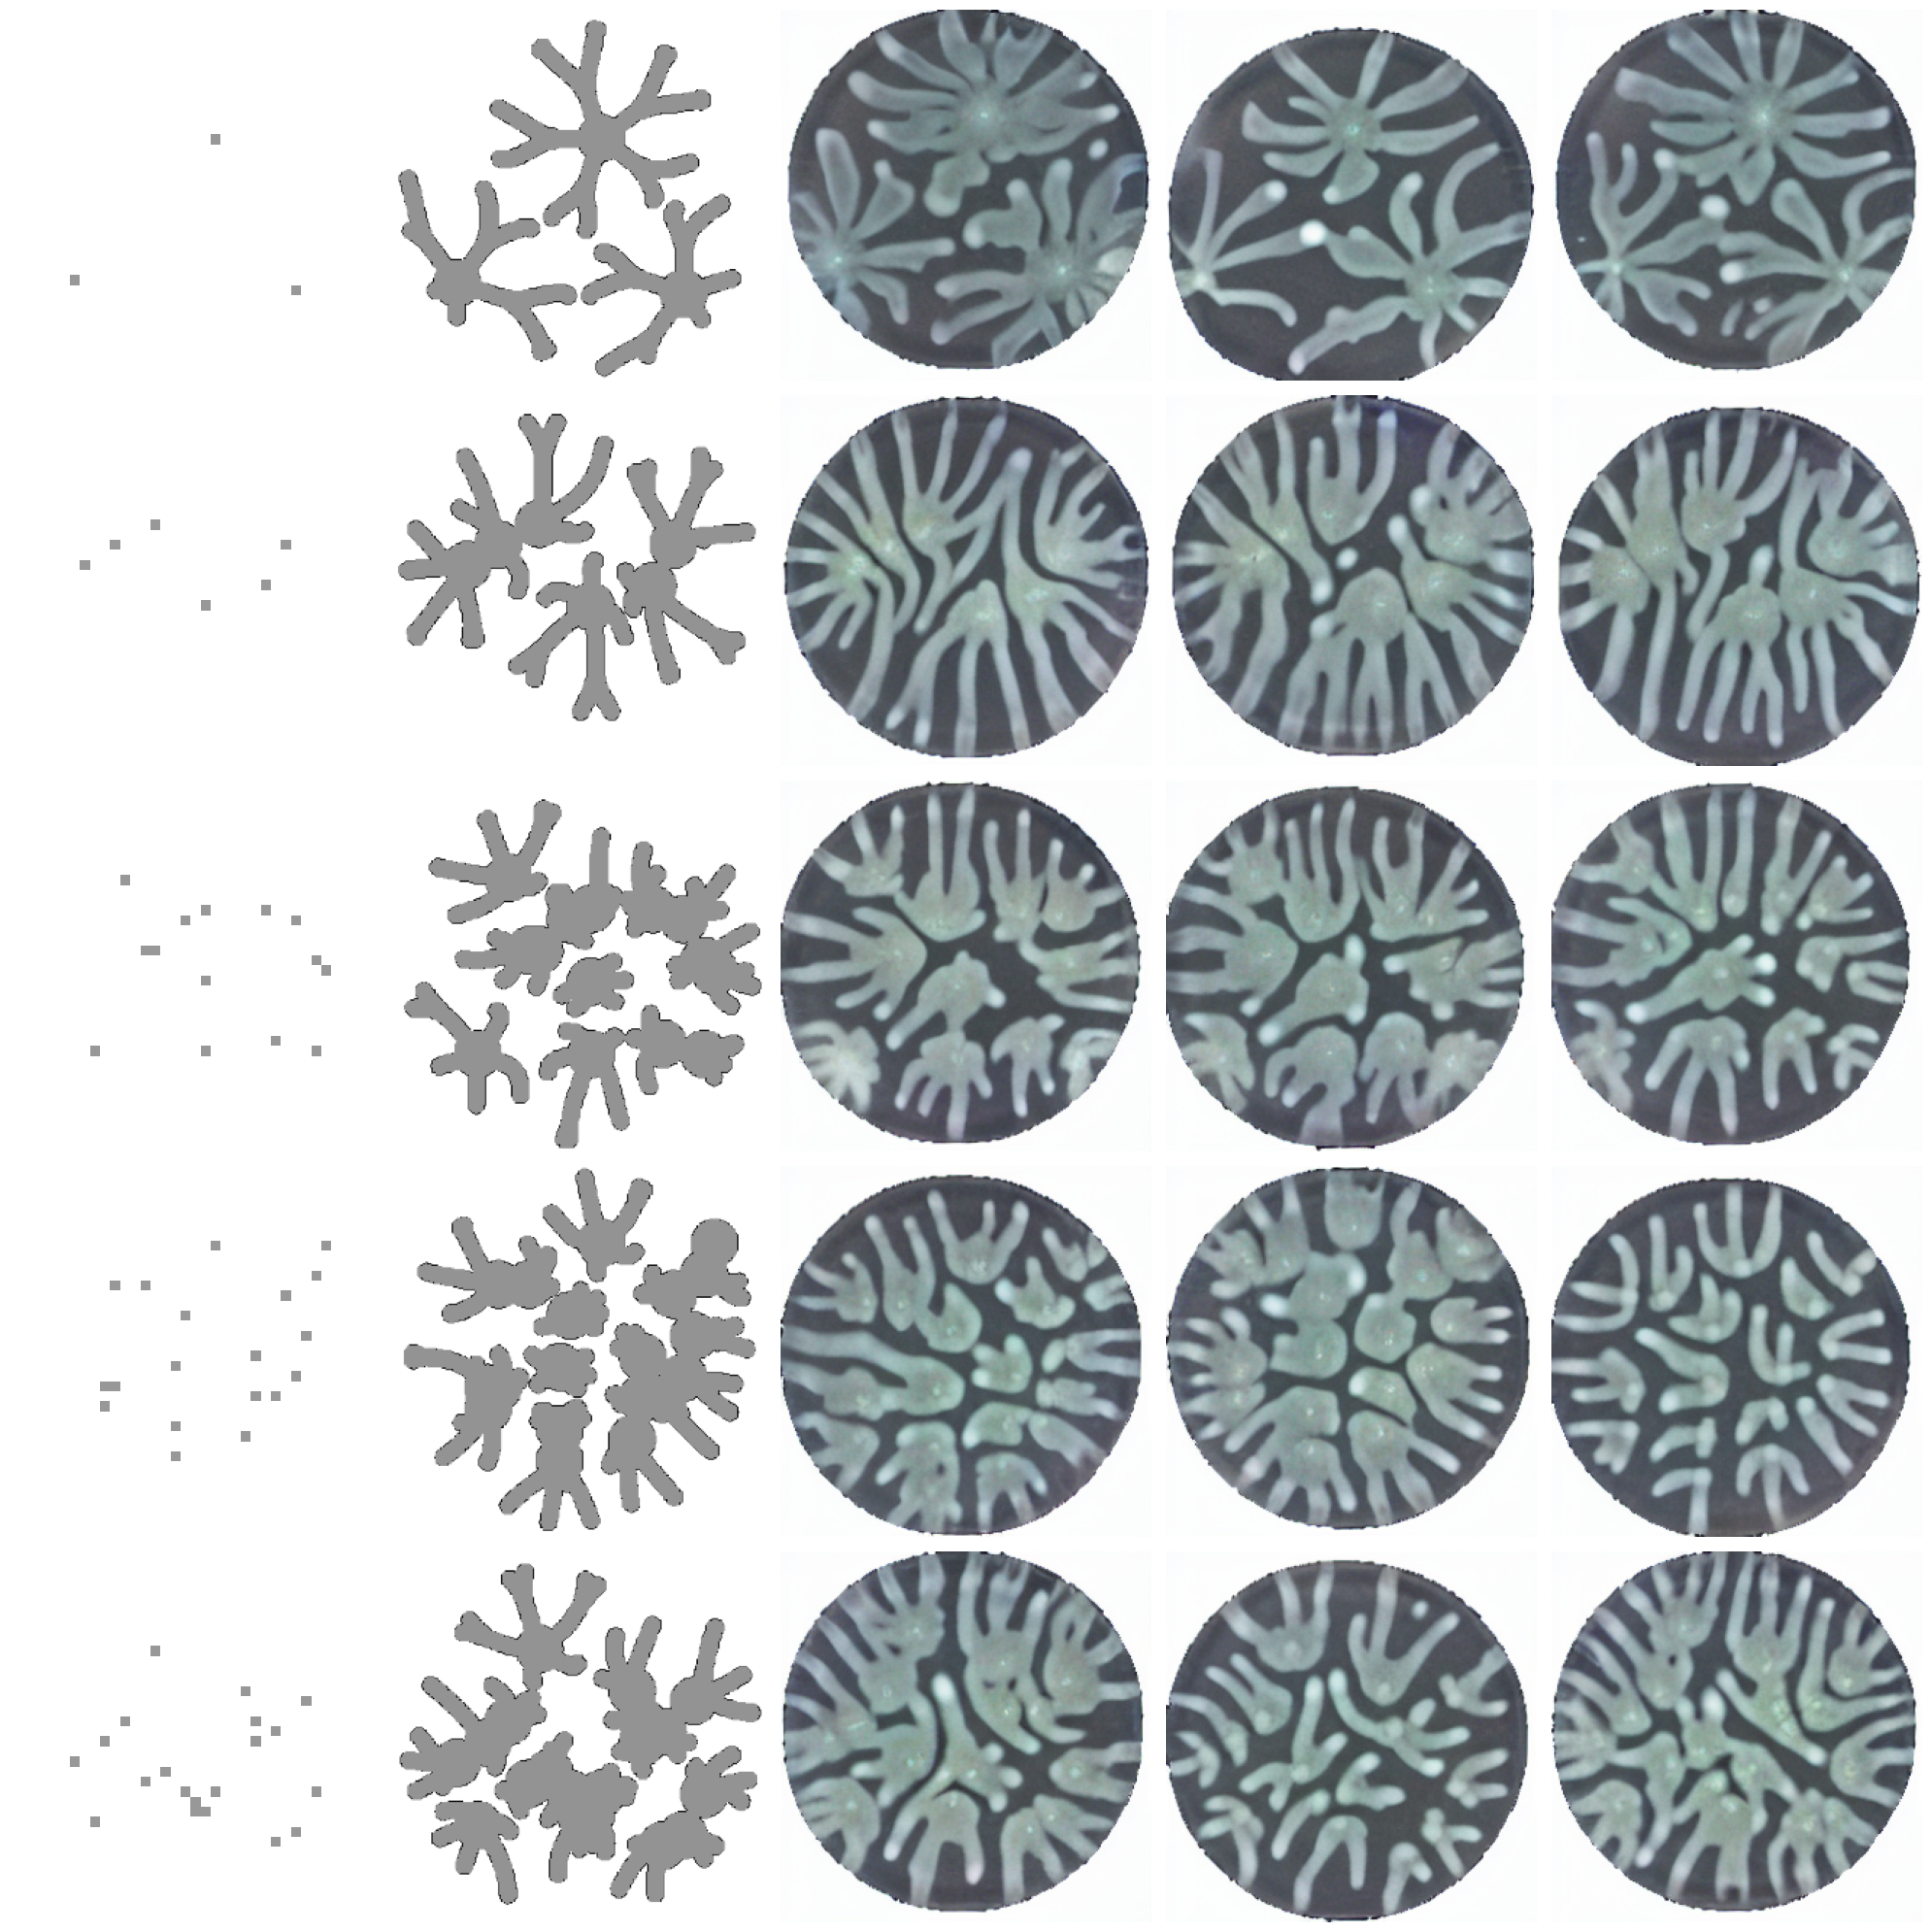

In [2]:
# For plotting figu 6a 
import matplotlib.pyplot as plt
import cv2
from utils.config import SIM_FOLDER_TEST_INFOENCODING_MORESEEDS, SEED_FOLDER_TEST_INFOENCODING_MORESEEDS, SPECIFIC_FOLDER_EXP_DIFFUSION_MORE
import os 
from utils.preprocess import preprocess_simulation_graybackground, grayfordisplay

# display 5 images of seed first, then simulations and then the diffusion model predictions (all 3 samples in the folder)

# for display purposes, select different amount of seeds from the folder 

input_selected_files= ['Input_5_10_111040.png', 'Input_5_10_128139.png', 'Input_5_10_380053.png','Input_5_10_308054.png','Input_5_10_24138.png', ]
# number of seeds               3                           6                      14                   19                         20                  

# for simulation files, just replace Input with Output and keep the rest of the file same

simulation_selected_files= [f.replace('Input', 'Output') for f in input_selected_files]

# for diffusion model files, we will replace simulation file names with an additional _1/_2/_3 at the end 
# rest of the file name is the same
add_modifiers= ['_1', '_2', '_3']
simulation_selected_files_without_extension= [os.path.splitext(f)[0] for f in simulation_selected_files]
diffusion_selected_files= [f"{name}{modifier}.png" for name in simulation_selected_files_without_extension for modifier in add_modifiers]

print(f"Input files: {input_selected_files}")
print(f"Simulation files: {simulation_selected_files}")
print(f"Diffusion files: {diffusion_selected_files}")

# Check if the images do exist in the respective folders
for file in input_selected_files:
    assert os.path.exists(os.path.join(SEED_FOLDER_TEST_INFOENCODING_MORESEEDS, file)), f"File {file} not found in {SEED_FOLDER_TEST_INFOENCODING_MORESEEDS}"

for file in simulation_selected_files:
    assert os.path.exists(os.path.join(SIM_FOLDER_TEST_INFOENCODING_MORESEEDS, file)), f"File {file} not found in {SIM_FOLDER_TEST_INFOENCODING_MORESEEDS}"

for file in diffusion_selected_files:
    assert os.path.exists(os.path.join(SPECIFIC_FOLDER_EXP_DIFFUSION_MORE, file)), f"File {file} not found in {SPECIFIC_FOLDER_EXP_DIFFUSION_MORE}"

# display images in a grid  with 5 rows  and  5 columns (1+1+3)

fig, axes = plt.subplots(5, 5, figsize=(20, 20))
for i in range(5):
    # display input image
    input_img = grayfordisplay(os.path.join(SEED_FOLDER_TEST_INFOENCODING_MORESEEDS, input_selected_files[i]), img_length= 32, img_width= 32, img_type= 'seed')
    axes[i, 0].imshow(input_img, cmap ='gray')
    # axes[i, 0].set_title(f"Input: {input_selected_files[i]}")
    axes[i, 0].axis('off')
    
    # display simulation image
    sim_img = preprocess_simulation_graybackground(os.path.join(SIM_FOLDER_TEST_INFOENCODING_MORESEEDS, simulation_selected_files[i]))
    axes[i, 1].imshow(sim_img, cmap ='gray')
    # axes[i, 1].set_title(f"Simulation: {simulation_selected_files[i]}")
    axes[i, 1].axis('off')
    
    # display diffusion model predictions (3 images for each simulation)
    for j in range(3):
        diffusion_file = diffusion_selected_files[i*3 + j]
        diffusion_img = cv2.imread(os.path.join(SPECIFIC_FOLDER_EXP_DIFFUSION_MORE, diffusion_file))
        diffusion_img = cv2.cvtColor(diffusion_img, cv2.COLOR_BGR2RGB)
        axes[i, j+2].imshow(diffusion_img)
        # axes[i, j+2].set_title(f"Diffusion: {diffusion_file}")
        axes[i, j+2].axis('off')

plt.tight_layout()
plt.show()

Figure 6e

/hpc/dctrl/ks723/miniconda3/envs/pytorch_PA_patternprediction/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2026-04-23 17:34:16,263] [INFO] [real_accelerator.py:110:get_accelerator] Setting ds_accelerator to cuda (auto detect)


/hpc/dctrl/ks723/miniconda3/envs/pytorch_PA_patternprediction/lib/python3.10/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


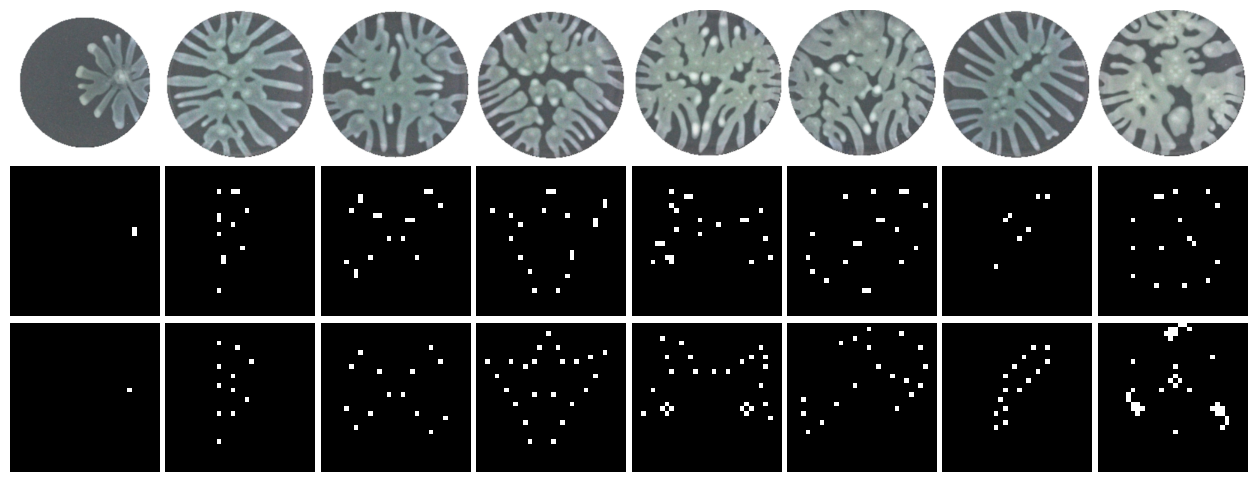

Displayed 8 images in specified order


In [2]:

import torch 
import os 
import cv2 
import matplotlib.pyplot as plt 
import numpy as np
from utils.config import CKPT_PATH_MORESEEDS_DIFFUSION
from utils.config import EXP_FOLDER_TEST, SEED_FOLDER_EXPTOSIM_TEST_32X32
from utils.config import EXP_FOLDER_EXPTOSIM_TEST_FIXED, SEED_FOLDER_EXPTOSIM_TEST_FIXED_32X32
from expcolortoseed_dataset import MyDataset
from models.UNet_Resblocks import UNet_Resblocks

# load the model 
model_path= CKPT_PATH_MORESEEDS_DIFFUSION
model= UNet_Resblocks.load_from_checkpoint(model_path)

# load the test set 
test_dataset= MyDataset(source_folder= EXP_FOLDER_TEST, target_folder= SEED_FOLDER_EXPTOSIM_TEST_32X32,use_vae=True)

# test the performance on the test set
model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)


# combine predictions on both these datasets

# files_selected= ['198_1.png', 'Fixed_8_2.TIF','Fixed_6_2.TIF', 'Fixed_7_1.TIF', 'Fixed_12_1.TIF','Fixed_13_2.TIF','Fixed_9_2.TIF', 'Fixed_19_1.TIF']
# combine predictions on both these datasets in specified order

# Desired display order
files_selected = ['198_1.png', 'Fixed_8_2.TIF', 'Fixed_6_2.TIF', 'Fixed_7_1.TIF',
                  'Fixed_12_1.TIF', 'Fixed_13_2.TIF', 'Fixed_9_2.TIF', 'Fixed_19_1.TIF']
selected_stems_ordered = [os.path.splitext(f)[0] for f in files_selected]
selected_stems_set     = set(selected_stems_ordered)

all_datasets = [
    MyDataset(source_folder=EXP_FOLDER_TEST,                target_folder=SEED_FOLDER_EXPTOSIM_TEST_32X32,       use_vae=True),
    MyDataset(source_folder=EXP_FOLDER_EXPTOSIM_TEST_FIXED, target_folder=SEED_FOLDER_EXPTOSIM_TEST_FIXED_32X32, use_vae=True),
]

results = {}  # stem -> (source_img, pred_img, target_img)
thresh_value = 0.6

model.eval()
with torch.no_grad():
    for dataset in all_datasets:
        for i in range(len(dataset)):
            sample = dataset[i]
            source = sample['source']
            target = sample['target']
            stem   = sample['stem']

            if stem not in selected_stems_set or stem in results:
                continue

            source_batch   = source.unsqueeze(0).to(device)
            source_encoded = model.encode_source(source_batch)
            pred           = torch.sigmoid(model(source_encoded))
            pred           = (pred > thresh_value).float().squeeze(0)

            results[stem] = (
                source_batch[0].permute(1, 2, 0).cpu().numpy(),
                (pred.cpu().numpy() * 255.0).astype(np.uint8),
                (target.cpu().numpy() * 255.0).astype(np.uint8),
            )

# Display in the exact order of files_selected
ordered = [results[s] for s in selected_stems_ordered if s in results]
n = len(ordered)

fig, axes = plt.subplots(3, n, figsize=(2 * n, 6))
for r, (src_img, pred_img, target_img) in enumerate(ordered):
    axes[0, r].imshow(src_img)
    axes[0, r].axis('off')
    axes[1, r].imshow(pred_img[0], cmap='gray')
    axes[1, r].axis('off')
    axes[2, r].imshow(target_img[0], cmap='gray')
    axes[2, r].axis('off')

plt.subplots_adjust(wspace=0.02, hspace=0.05)
plt.show()
print(f"Displayed {n} images in specified order")

Supplementary Figure 20

/hpc/dctrl/ks723/miniconda3/envs/pytorch_PA_patternprediction/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2026-05-07 16:05:25,494] [INFO] [real_accelerator.py:110:get_accelerator] Setting ds_accelerator to cuda (auto detect)


/hpc/dctrl/ks723/miniconda3/envs/pytorch_PA_patternprediction/lib/python3.10/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


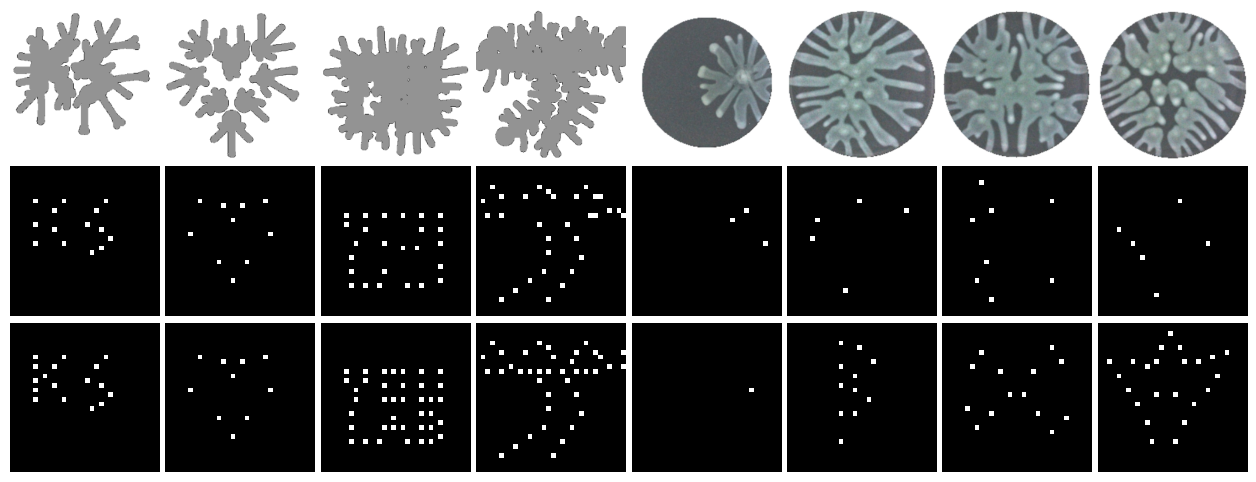

Displayed 8 images in specified order


In [1]:
from utils.config import CKPT_PATH_SEEDTOSIM_MORESEEDS_3ROTREPS
from utils.config import EXP_FOLDER_TEST, SEED_FOLDER_EXPTOSIM_TEST_32X32
from expcolortoseed_dataset import MyDataset
from simtoseed_dataset import MyDataset as MySimToSeedDataset
from models.UNet_Resblocks import UNet_Resblocks
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

# load the model 
model_path= CKPT_PATH_SEEDTOSIM_MORESEEDS_3ROTREPS
model= UNet_Resblocks.load_from_checkpoint(model_path)

from utils.config import EXP_FOLDER_EXPTOSIM_TEST_FIXED, SEED_FOLDER_EXPTOSIM_TEST_FIXED_32X32
from utils.config import EXP_FOLDER_TEST, SEED_FOLDER_EXPTOSIM_TEST_32X32
from utils.config import SIM_FOLDER_SEEDTOSIM_TEST, SEED_FOLDER_SEEDTOSIM_TEST


# Desired display order
files_selected = ['Output_3.png','Output_6.png','Output_4.png','Output_7.png','198_1.png', 'Fixed_8_2.TIF', 'Fixed_6_2.TIF', 'Fixed_7_1.TIF']
selected_stems_ordered = [os.path.splitext(f)[0] for f in files_selected]
selected_stems_set     = set(selected_stems_ordered)

# for target folder in MySimtoSeedDataset, we will convert names from Output_ to Input_
# so for example, if we have Output_3.png in files_selected, we will look for Input_3.png in the target folder of MySimToSeedDataset

files_selected_simtoseed = [f.replace('Output', 'Input') for f in files_selected if f.startswith('Output')]
selected_stems_ordered_simtoseed = [os.path.splitext(f)[0] for f in files_selected_simtoseed]
selected_stems_set_simtoseed     = set(selected_stems_ordered_simtoseed)

all_datasets = [
    MyDataset(source_folder=EXP_FOLDER_TEST,                target_folder=SEED_FOLDER_EXPTOSIM_TEST_32X32,       use_vae=True),
    MyDataset(source_folder=EXP_FOLDER_EXPTOSIM_TEST_FIXED, target_folder=SEED_FOLDER_EXPTOSIM_TEST_FIXED_32X32, use_vae=True),
    MySimToSeedDataset(source_folder=SIM_FOLDER_SEEDTOSIM_TEST, target_folder=SEED_FOLDER_SEEDTOSIM_TEST, use_vae=True),
]

results = {}  # stem -> (source_img, pred_img, target_img)
thresh_value = 0.6

# test the performance on the test set
model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)


with torch.no_grad():
    for dataset in all_datasets:
        for i in range(len(dataset)):
            sample = dataset[i]
            source = sample['source']
            target = sample['target']
            stem   = sample['stem']

            if (stem not in selected_stems_set and stem not in selected_stems_set_simtoseed) or stem in results:
                continue

            source_batch   = source.unsqueeze(0).to(device)
            source_encoded = model.encode_source(source_batch)
            pred           = torch.sigmoid(model(source_encoded))
            pred           = (pred > thresh_value).float().squeeze(0)

            results[stem] = (
                source_batch[0].permute(1, 2, 0).cpu().numpy(),
                (pred.cpu().numpy() * 255.0).astype(np.uint8),
                (target.cpu().numpy() * 255.0).astype(np.uint8),
            )

# Display in the exact order of files_selected
ordered = [results[s] for s in selected_stems_ordered if s in results]
n = len(ordered)

fig, axes = plt.subplots(3, n, figsize=(2 * n, 6))
for r, (src_img, pred_img, target_img) in enumerate(ordered):
    axes[0, r].imshow(src_img, cmap='gray' if src_img.shape[2] == 1 else None)
    axes[0, r].axis('off')
    axes[1, r].imshow(pred_img[0], cmap='gray')
    axes[1, r].axis('off')
    axes[2, r].imshow(target_img[0], cmap='gray')
    axes[2, r].axis('off')

plt.subplots_adjust(wspace=0.02, hspace=0.05)
plt.show()
print(f"Displayed {n} images in specified order")